# NESTML Tutorial

### Neuromorphic Hardware and Algorithms (NHA2026) — 11–12 June 2026, University of Sussex, Brighton, UK

**Tutor:** Ariel Shmilli ([a.shmilli@sussex.ac.uk](mailto:a.shmilli@sussex.ac.uk))

---

## What is NESTML?

NESTML is a domain-specific modelling language for neuron and synapse models, developed primarily for the [NEST simulator](https://www.nest-simulator.org/). Rather than writing low-level C++ by hand, NESTML lets you express model dynamics in a clean, equation-oriented syntax. It then automatically generates, compiles, and installs the corresponding code.

### Design principles

NESTML is built around three core ideas:


- **Accessibility**: Models are written in a syntax close to mathematical notation, making them readable without C++ or NEST internals knowledge.
- **Flexibility**: The processing toolchain (**PyNESTML**) is written in Python and can be extended or customised.
- **Performance**: Output is optimised C++ code, achieving the same execution speed as hand-written NEST models.

### Type system and physical units

NESTML enforces physical units at compile time, eliminating an entire class of dimensional-analysis bugs common in hand-written models. The type system combines:

- **Primitive types**: `real`, `integer`, `boolean`, `string`
- **Physical unit types**: built from the seven SI base units (m, kg, s, A, K, mol, cd) and 24 named derived units (V, F, S, Hz, …), with all standard SI magnitude prefixes (pF, mV, nS, pA, …)

Unit-typed and dimensionless variables can interact (with a compiler warning), but conversions across categorical boundaries (e.g. numeric ↔ boolean) are forbidden.

### Key language features

**Differential equations** — The `equations` block accepts systems of ODEs of arbitrary order using prime notation (`V_m'`, `V_m''`, …). Delay differential equations are also supported, allowing state variables to be referenced at a past time: `foo' = bar(t - delay) / tau`.

**Kernel functions** — Kernels define time-varying convolution shapes (e.g. exponential, alpha/double-exponential, Dirac delta) that are convolved with spike trains to produce synaptic conductance or current waveforms. They can be declared as direct time functions, as differential equations, or as combinations.

**Conditional event handlers** — The `onReceive` block executes at each incoming spike; `onCondition` triggers on an arbitrary boolean guard. Both support ordering priorities when multiple events coincide.

**Vectors** — State variables and parameters can be declared as fixed- or variable-length vectors (e.g. for multi-compartment models), indexed with bracket notation.

**Inline expressions** — Named scalar expressions are expanded at compile time, keeping the ODE block readable without runtime overhead.

**Predefined functions** — 30+ built-ins including `min`, `max`, `abs`, `exp`, trigonometric functions, `convolve`, `integrate_odes`, `emit_spike`, `random_normal`, `random_poisson`, and simulator timing utilities (`resolution()`, `steps()`).

### Supported targets

The primary compilation target is the NEST Simulator. Because code generation is driven by Jinja2 templates, the architecture is extensible to other platforms (e.g. SpiNNaker, Brian2) by providing a new template set.

| Resource | Link |
|----------|------|
| Documentation | [nestml.readthedocs.io](https://nestml.readthedocs.io/en/latest/) |
| Source code | [github.com/nest/nestml](https://github.com/nest/nestml) |
| Reference | Charl Linssen, Pooja N. Babu, Andreas Rogalski, Bernhard Rumpe and Abigail Morrison (2025). *NESTML 8.2.0*. Zenodo. [doi:10.5281/zenodo.16537793](https://doi.org/10.5281/zenodo.16537793) |

---

## NESTML model structure

A NESTML model is composed of named *blocks*, each serving a specific role:

| Block | Description |
|-------|-------------|
| `parameters` | Constants that do not change during a simulation |
| `internals` | Derived constants computed from parameters |
| `state` | Variables that evolve over time |
| `input` | Input ports — spikes or continuous signals (e.g. injected current) |
| `output` | The event type emitted by the model (currently spike output only) |
| `equations` | ODEs and inline expressions describing the model dynamics |
| `update` | Statements executed at every simulation time step |
| `onReceive` | Handler executed when a spike input arrives |
| `onCondition` | Handler triggered when a logical condition becomes true |

Full reference: [NESTML language concepts](https://nestml.readthedocs.io/en/latest/nestml_language/nestml_language_concepts.html)

---

## Notebook overview

This notebook is based on the [NESTML AdEx model](https://github.com/nest/nestml/blob/main/models/neurons/aeif_cond_alpha_neuron.nestml) (credit: Charl Linssen and Pooja Babu) and was adapted for the NHA2026 workshop.

**Contents:**

1. **The Adaptive Exponential Integrate-and-Fire (AdEx) neuron**: write the model in NESTML, compile it, and simulate four representative firing regimes according to [[4]](https://link.springer.com/article/10.1007/s00422-008-0264-7).
2. **The Tsodyks-Markram synapse with short-term plasticity**: implement depression and facilitation in NESTML and connect pre- and postsynaptic neurons.

## 1. The Adaptive Exponential Integrate-and-Fire (AdEx) neuron model

In this section we write the AdEx neuron model [[1]](https://pubmed.ncbi.nlm.nih.gov/16014787/) from scratch in NESTML, compile it, and use it in a NEST simulation to explore the range of firing dynamics the model can reproduce.

The AdEx neuron is described by the following set of equations:

$$
\begin{cases}
    C \frac{dV}{dt} = -g_L(V - E_L) + g_L \Delta_T \exp\!\left(\frac{V - V_T}{\Delta_T}\right) - w + I \\[6pt]
    \tau_w \frac{dw}{dt} = a(V - E_L) - w
\end{cases}
$$

Where $V$ is the membrane potential and $w$ is the adaptation current.
The first equation extends the standard Leaky Integrate-and-Fire model with an
exponential nonlinearity: as $V$ approaches the effective threshold $V_T$, the
exponential term drives a rapid upswing that mimics the onset of a real action
potential. The second equation describes a slow adaptation current that provides
negative feedback to $V$ on longer timescales.

When the membrane potential reaches a cutoff value $V_\text{peak}$, the
variables are reset following:

$$
\begin{cases}
    V \leftarrow V_r \\
    w \leftarrow w + b
\end{cases}
$$

The model parameters and their roles are:

| Symbol | Description |
|--------|-------------|
| $C$ | Membrane capacitance |
| $g_L$ | Leak conductance |
| $E_L$ | Resting (leak reversal) potential |
| $\Delta_T$ | Slope factor controlling the sharpness of spike initiation |
| $V_T$ | Effective threshold potential (where the exponential activates) |
| $\tau_w$ | Adaptation time constant |
| $a$ | Subthreshold adaptation coupling (conductance between $V$ and $w$) |
| $b$ | Spike-triggered adaptation increment |
| $V_r$ | Reset potential after a spike |

The AdEx model is a conceptual hybrid: it combines the biophysically motivated
exponential spike initiation [[2]](https://pubmed.ncbi.nlm.nih.gov/14684865/) with the two-variable
adaptation structure of the Izhikevich model [[3]](https://pubmed.ncbi.nlm.nih.gov/18244602/). By tuning $a$, $b$, $\tau_w$,
and the reset parameters, it can reproduce a wide range of cortical firing patterns
while keeping the parameter set small and physiologically interpretable.

A key advantage of the AdEx is that all parameters have clear biophysical meaning
and can in principle be estimated from standard current-clamp protocols (step and
ramp current injections). Brette and Gerstner showed that with parameters fitted to
a detailed conductance-based regular spiking neuron, the AdEx correctly predicted
the timing of 96% of spikes (±2 ms) under noisy synaptic input, and was
particularly reliable in high-conductance states typical of cortical activity in vivo.

The main limitation is the non-physical blow-up of $V$ at spike time, which
requires an explicit cutoff $V_\text{peak}$ and reset rule. Compared to simpler
integrate-and-fire models, the AdEx is somewhat more expensive to simulate due to
the additional term, but remains far cheaper than full conductance-based models.

### References

[1] R. Brette and W. Gerstner, "Adaptive exponential integrate-and-fire model as
an effective description of neuronal activity", *Journal of Neurophysiology*,
vol. 94, no. 5, pp. 3637–3642, Nov. 2005, doi: 10.1152/jn.00686.2005.

[2] N. Fourcaud-Trocmé, D. Hansel, C. van Vreeswijk, and N. Brunel,
"How spike generation mechanisms determine the neuronal response to fluctuating
inputs", *Journal of Neuroscience*, vol. 23, no. 37, pp. 11628–11640, Dec. 2003,
doi: 10.1523/JNEUROSCI.23-37-11628.2003.

[3] E. M. Izhikevich, "Simple model of spiking neurons", *IEEE Transactions on
Neural Networks*, vol. 14, no. 6, pp. 1569–1572, Nov. 2003,
doi: 10.1109/TNN.2003.820440.

[4] R. Naud, N. Marcille, C. Clopath, and W. Gerstner, "Firing patterns in the
adaptive exponential integrate-and-fire model", *Biological Cybernetics*,
vol. 99, no. 4–5, pp. 335–347, Nov. 2008, doi: 10.1007/s00422-008-0264-7.

### 1.2. NESTML neuron model

We begin by importing the necessary Python libraries and configuring NEST's verbosity.

In [1]:
%matplotlib widget
import matplotlib.pyplot as plt
import nest
import numpy as np
from pynestml.codegeneration.nest_code_generator_utils import NESTCodeGeneratorUtils # type: ignore
from pynestml.frontend import pynestml_frontend # pyright: ignore[reportMissingImports]

nest.set_verbosity("M_FATAL")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Apr 14 2026 11:35:50

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



The AdEx model is defined below as a NESTML string. Each block (`parameters`, `state`, `equations`, `update`, `onCondition`) corresponds to a conceptual part of the model described above.

In [2]:
neuron_model = """
model aeif_neuron:
    parameters:
        # membrane parameters
        C_m pF = 281.0 pF              # Membrane capacitance
        refr_T ms = 2 ms               # Duration of refractory period
        V_reset mV = -60.0 mV          # Reset potential
        g_L nS = 30.0 nS               # Leak conductance
        E_L mV = -70.6 mV              # Leak reversal potential (resting potential)

        # spike adaptation parameters
        a nS = 4 nS                    # Subthreshold adaptation
        b pA = 80.5 pA                 # Spike-triggered adaptation
        Delta_T mV = 2.0 mV            # Slope factor
        tau_w ms = 144.0 ms            # Adaptation time constant
        V_th mV = -50.4 mV             # Spike initiation threshold
        V_peak mV = 0 mV               # Spike detection threshold

        # synaptic parameters
        E_exc mV = 0 mV                # Excitatory reversal potential
        tau_syn_exc ms = 0.2 ms        # Synaptic time constant excitatory synapse
        E_inh mV = -85.0 mV            # Inhibitory reversal potential
        tau_syn_inh ms = 2.0 ms        # Synaptic time constant for inhibitory synapse

        # Constant external input current
        I_e pA = 0 pA

    input:
        exc_spikes <- excitatory spike
        inh_spikes <- inhibitory spike
        I_stim pA <- continuous

    output:
        spike

    state:
        V_m mV = E_L        # Membrane potential
        w pA = 0 pA         # Spike-adaptation current
        refr_t ms = 0 ms    # Refractory period timer

    equations:
        inline V_bounded mV = min(V_m, V_peak) # prevent exponential divergence
        kernel g_inh = (e / tau_syn_inh) * t * exp(-t / tau_syn_inh)
        kernel g_exc = (e / tau_syn_exc) * t * exp(-t / tau_syn_exc)

        # Add inlines to simplify the equation definition of V_m
        inline I_spike pA = g_L * Delta_T * exp((V_bounded - V_th) / Delta_T)
        inline I_syn_exc pA = convolve(g_exc, exc_spikes) * (V_bounded - E_exc) * nS
        inline I_syn_inh pA = convolve(g_inh, inh_spikes) * (V_bounded - E_inh) * nS
        
        V_m' = (-g_L * (V_bounded - E_L) + I_spike - I_syn_exc - I_syn_inh - w + I_e + I_stim) / C_m
        w' = (a * (V_bounded - E_L) - w) / tau_w

        refr_t' = -1e3 * ms/s    # refractoriness is implemented as an ODE, representing a timer counting back down to zero.

    update:
        if refr_t > 0 ms:
            # neuron is absolute refractory, do not evolve V_m
            integrate_odes(w, refr_t)
        else:
            # neuron not refractory
            integrate_odes(V_m, w)

    onCondition(refr_t <= 0 ms and V_m >= V_peak):
        # threshold crossing
        refr_t = refr_T    # start of the refractory period
        V_m = V_reset
        w += b
        emit_spike()
"""

`NESTCodeGeneratorUtils.generate_code_for()` parses the NESTML string, generates optimised C++ code, compiles it into a loadable NEST module, and returns the module and model names needed to instantiate neurons. This may take a few seconds on the first run.

In [3]:
module_name, neuron_model_name = NESTCodeGeneratorUtils.generate_code_for(neuron_model, target_path="./target")


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Apr 14 2026 11:35:50

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[12,aeif_neuron_nestml, WARNING, [12:8;12:17]]: Variable 'a' has the same name as a physical unit!


### 1.3. Simulating the neuron

By tuning the parameters of the AdEx model, a wide variety of cortical firing
patterns can be reproduced [[4]](https://pubmed.ncbi.nlm.nih.gov/19011922/).
We simulate four representative regimes in response to a step current injection:

| Regime | Key parameters | Description |
|--------|---------------|-------------|
| **Adapting** | $a > 0$, $b > 0$, large $\tau_w$ | The neuron fires tonically but with progressively increasing interspike intervals, reflecting the build-up of the adaptation current $w$ over time. |
| **Initial bursting** | $a > 0$, large $b$, short $\tau_w$ | The neuron emits a burst of spikes at the onset of stimulation, then settles into a slower tonic firing rate as $w$ accumulates. |
| **Delayed accelerating** | $a < 0$, $b = 0$ | Negative subthreshold adaptation initially opposes firing; once $V$ escapes this brake, spiking accelerates. |
| **Irregular spiking** | $a < 0$, small $b$ | The neuron fires aperiodically in a regime of deterministic chaos; spike times are highly sensitive to initial conditions. |

The parameter dictionary below encodes one set of values for each regime.

In [4]:
patterns_dict = {
    "Adapting": {"C_m": 200, "g_L": 12, "E_L": -70, "V_th": -50, "Delta_T": 2, "a": 2, "tau_w": 300, "b": 60, "V_reset": -58, "I_e": 500},
    "Initial burst": {"C_m": 130, "g_L": 18, "E_L": -58, "V_th": -50, "Delta_T": 2, "a": 4, "tau_w": 150, "b": 120, "V_reset": -50, "I_e": 400},
    "Delayed accelerating": {"C_m": 200, "g_L": 12, "E_L": -70, "V_th": -50, "Delta_T": 2, "a": -10, "tau_w": 300, "b": 0, "V_reset": -58, "I_e": 300},
    "Irregular": {"C_m": 100, "g_L": 12, "E_L": -60, "V_th": -50, "Delta_T": 2, "a": -11, "tau_w": 130, "b": 30, "V_reset": -48, "I_e": 160},
}

For each regime we reset the NEST kernel, instantiate one neuron with the regime-specific parameters, attach a multimeter, run a 300 ms simulation, and plot the membrane potential $V_m$ (black) alongside the adaptation current $w$ (red, right axis).

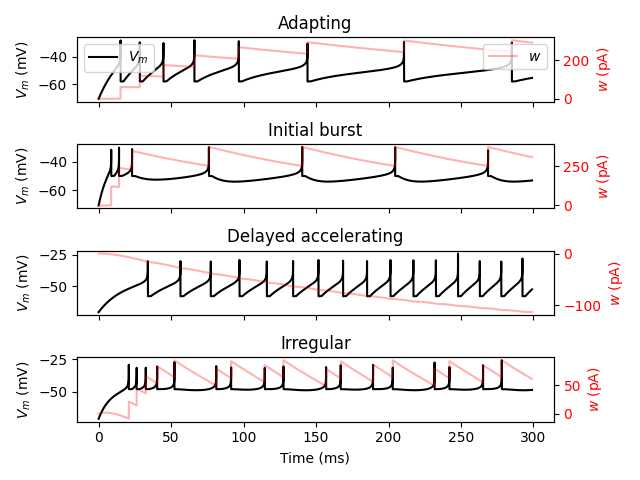

In [5]:
fig, ax = plt.subplots(len(patterns_dict), 1, sharex=True)

resolution = 0.001

for i, (pattern, neuron_params) in enumerate(patterns_dict.items()):
    nest.ResetKernel()
    nest.Install(module_name)
    nest.set(**{"resolution": resolution})

    neuron = nest.Create(neuron_model_name, params=neuron_params)
    mm = nest.Create("multimeter", params={"record_from": ["V_m", "w"], "interval": resolution})

    nest.Connect(mm, neuron)
    nest.Simulate(300)

    events = mm.get("events")

    time = events["times"]
    v = events["V_m"]
    w = events["w"]

    ax2 = ax[i].twinx()

    ax[i].plot(time, v, color="k", label="$V_m$")
    ax2.plot(time, w, color="r", label="$w$", alpha=0.3)

    ax[i].set_title(f"{pattern}")
    ax[i].set_ylabel("$V_m$ (mV)", color="k")
    ax2.set_ylabel("$w$ (pA)", color="r")
    ax[i].tick_params(axis="y", labelcolor="k")
    ax2.tick_params(axis="y", labelcolor="r")

    if i == 0:
        ax[i].legend(loc="upper left")
        ax2.legend(loc="upper right")

ax[-1].set_xlabel("Time (ms)")
plt.tight_layout()
plt.show()

---

# 2. The Tsodyks-Markram synapse model with short-term plasticity

Short-term synaptic plasticity is a transient change in synaptic efficacy lasting milliseconds to seconds. Unlike long-term plasticity, which can persist for hours, it decays back to baseline quickly. The Tsodyks-Markram model [[5](https://doi.org/10.1162/089976698300017502), [6](https://doi.org/10.1523/JNEUROSCI.20-01-j0003.2000)] captures two opposing forms: short-term depression and short-term facilitation.

The model tracks synaptic vesicle resources across three discrete states:

| Variable | State | Description |
|----------|-------|-------------|
| $x$ | Recovered | Readily releasable pool (available for release) |
| $y$ | Active | Resources currently in the synaptic cleft |
| $z$ | Inactive | Depleted resources undergoing recycling |

The three fractions always sum to one: $x + y + z = 1$.

### Dynamics

Between presynaptic spikes, the fractions evolve continuously:

$$\frac{dx}{dt} = \frac{z}{\tau_\text{rec}} - u_+ x_- \,\delta(t - t_j^f)$$

$$\frac{dy}{dt} = -\frac{y}{\tau_{psc}} + u_+ x_- \,\delta(t - t_j^f)$$

$$\frac{dz}{dt} = \frac{y}{\tau_{psc}} - \frac{z}{\tau_\text{rec}}$$

where $\tau_I$ is the PSC decay constant, $\tau_\text{rec}$ is the recovery time from depression, and $t_j^f$ are the presynaptic spike times. The subscripts $\pm$ denote values taken just after and just before an update. At each spike, a fraction $u_+$ of the recovered resources $x$ moves into the active state.

The synaptic current delivered to the postsynaptic neuron is $w \cdot y(t)$, where $w$ is the absolute synaptic weight.

### Short-term depression

With a large release fraction ($U = 0.5$), each spike draws heavily on the available pool. When spikes arrive faster than $\tau_\text{rec}$ can refill $x$, the recovered fraction runs down and successive PSPs get smaller. That drop is the signature of vesicle depletion: the readily releasable pool empties faster than it recovers.

### Short-term facilitation

In facilitating synapses, $u_+$ isn't fixed. It comes from a dynamic variable $u$:

$$\frac{du}{dt} = -\frac{u}{\tau_\text{fac}} + U(1 - u_-)\,\delta(t - t_j^f)$$

Start with a small baseline probability ($U = 0.03$) and a long $\tau_\text{fac}$, and each spike nudges $u$ upward before it has time to decay. The release fraction climbs spike after spike, so successive PSPs grow instead of shrinking. Physically, this is residual presynaptic calcium pushing the release probability up.

### Parameter summary

| Parameter | Role | Depression | Facilitation |
|-----------|------|-----------|-------------|
| $U$ | Baseline release probability / facilitation increment | $0.5$ (large) | $0.03$ (small) |
| $\tau_\text{rec}$ | Recovery from depression (ms) | $800$ | $130$ |
| $\tau_\text{fac}$ | Facilitation time constant (ms) | $0$ (disabled) | $530$ |

### References

[5] Tsodyks M, Pawelzik K, Markram H (1998), "Neural networks with dynamic synapses", Neural Computation, doi:10.1162/089976698300017502

[6] Tsodyks M, Uziel A, Markram H (2000), "Synchrony generation in recurrent networks with frequency-dependent synapses", Journal of Neuroscience, 20 RC50, doi:10.1523/JNEUROSCI.20-01-j0003.2000

The NESTML implementation of the Tsodyks-Markram synapse is shown below. The `onReceive` block handles all dynamics: it first analytically propagates the resource fractions $x$, $y$, $z$ and the release probability $u$ from the last spike time to the current spike, then applies the discrete spike-triggered updates and emits a weighted spike.

In [6]:
synapse_model = """
model tsodyks_synapse:
    parameters:
        w real = 1
        tau_psc ms = 3 ms
        tau_fac ms = 130 ms
        tau_rec ms = 0 ms
        U real = .5
        syn_delay ms = 1 ms

    state:
        x real = 1
        y real = 0
        z real = 0
        u real = U
        w_tot real = 1
        t_last_update ms = 0 ms

    input:
        pre_spikes <- spike

    output:
        spike(weight real, delay ms)

    onReceive(pre_spikes):
        dt ms = t - t_last_update
        t_last_update = t

        Puu real = tau_fac == 0 ? 0 : exp(-dt / tau_fac)
        Pyy real = exp(-dt / tau_psc)
        Pzz real = exp(-dt / tau_rec)
        Pxy real = ((Pzz - 1) * tau_rec - (Pyy - 1) * tau_psc) / (tau_psc - tau_rec)
        Pxz real = 1 - Pzz

        # depress synapse
        u *= Puu
        x += Pxy * y + Pxz * z
        y *= Pyy
        z = 1 - x - y
        u += U * (1 - u)

        delta_y_tsp real = u * x
        x -= delta_y_tsp
        y += delta_y_tsp

        w_tot = delta_y_tsp * w

        # deliver spike to postsynaptic partner
        emit_spike(w_tot, syn_delay)
"""

Here we compile both the neuron and the synapse together into a single NEST module. The `weight_variable` / `delay_variable` identify which synapse state variables carry the effective synaptic weight and transmission delay.

In [7]:
options = {"weight_variable": {"tsodyks_synapse": "w_tot"},
           "delay_variable": {"tsodyks_synapse": "syn_delay"}}

module_name, neuron_model_name, synapse_model_name = \
    NESTCodeGeneratorUtils.generate_code_for(neuron_model, synapse_model, target_path="./target", post_ports=[], codegen_opts=options)


              -- N E S T --
  Copyright (C) 2004 The NEST Initiative

 Version: 3.9.0
 Built: Apr 14 2026 11:35:50

 This program is provided AS IS and comes with
 NO WARRANTY. See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

[19,tsodyks_synapse_nestml, WARNING, [29:19;29:30]]: Operands of logical comparison operator not compatible.
[21,aeif_neuron_nestml, WARNING, [12:8;12:17]]: Variable 'a' has the same name as a physical unit!


We create a population of 100 pre-synaptic AdEx neurons (Adapting regime, no DC input) connected via Tsodyks-Markram synapses to a single post-synaptic neuron (Irregular regime). Two Poisson generators deliver bursts of excitatory drive to the pre-synaptic population at different time windows. The synaptic state of one representative connection is recorded at every simulation step.

In [8]:
res = 0.1

nest.ResetKernel()
nest.Install(module_name)

for model in patterns_dict.keys(): patterns_dict[model]["I_e"] = 0

pre = nest.Create(neuron_model_name, n=100, params=patterns_dict["Adapting"])
post = nest.Create(neuron_model_name, params=patterns_dict["Irregular"])
sg1 = nest.Create("poisson_generator", params={"rate": 30000, "start": 200, "stop": 1000})
sg2 = nest.Create("poisson_generator", params={"rate": 30000, "start": 1500})
mm_pre = nest.Create("multimeter", params={"record_from": ["V_m"], "interval": res})
mm_post = nest.Create("multimeter", params={"record_from": ["V_m"], "interval": res})

nest.Connect(pre, post, syn_spec={"synapse_model": synapse_model_name})
nest.Connect(sg1, pre)
nest.Connect(sg2, pre)
nest.Connect(mm_pre, pre[0])
nest.Connect(mm_post, post)

syn = nest.GetConnections(source=pre[0])

sim_time = 2000
n_steps = int(sim_time / res)

time = np.linspace(0, sim_time / 1000, n_steps)

x = np.zeros(n_steps)
y = np.zeros(n_steps)
z = np.zeros(n_steps)
w = np.zeros(n_steps)

for i in range(n_steps):
    nest.Simulate(res)
    vars = syn.get(["x", "y", "z", "w_tot"])
    x[i] = vars["x"]
    y[i] = vars["y"]
    z[i] = vars["z"]
    w[i] = vars["w_tot"]

The plot shows the evolution of the three resource fractions $x$ (recovered, red), $y$ (active, orange), $z$ (inactive, green) and the effective synaptic weight $w_{\mathrm{tot}}$ (blue) over time. The depletion of $x$ during the active burst and its gradual recovery during the silent interval are the hallmarks of short-term depression.

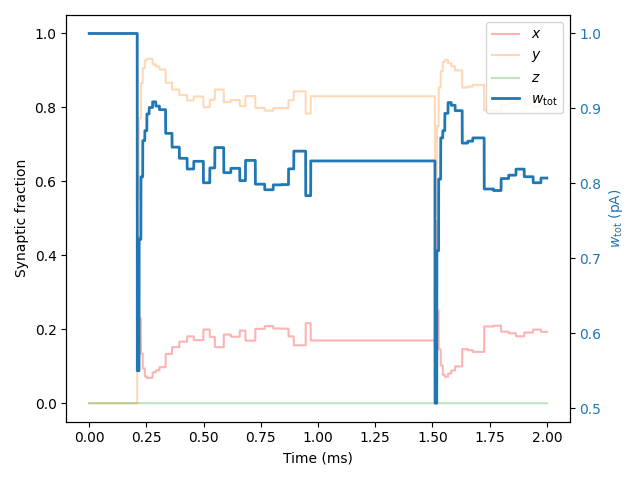

In [9]:
fig, ax = plt.subplots()
ax2 = ax.twinx()

ax.plot(time, x, color="r", label="$x$", alpha=0.3)
ax.plot(time, y, color="tab:orange", label="$y$", alpha=0.3)
ax.plot(time, z, color="tab:green", label="$z$", alpha=0.3)
ax2.plot(time, w, color="tab:blue", label=r"$w_\mathrm{tot}$", linewidth=2)

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Synaptic fraction", color="k")
ax2.set_ylabel(r"$w_\mathrm{tot}$ (pA)", color="tab:blue")
ax.tick_params(axis="y", labelcolor="k")
ax2.tick_params(axis="y", labelcolor="tab:blue")

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()

Finally, we compare the membrane potentials of one representative presynaptic neuron and the postsynaptic one. The post-synaptic response reflects both the incoming pre-synaptic spike train and the short-term depression shaping the effective synaptic weight.

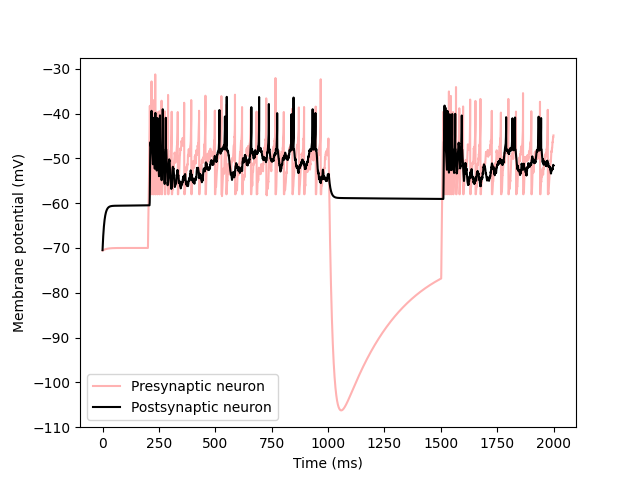

In [10]:
time_mm = mm_pre.get("events")["times"]
v_pre = mm_pre.get("events")["V_m"]
v_post = mm_post.get("events")["V_m"]

v_th = post.get("V_th")

plt.figure()
plt.plot(time_mm, v_pre, label="Presynaptic neuron", color="r", alpha=0.3)
plt.plot(time_mm, v_post, label="Postsynaptic neuron", color="k")
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.legend(loc="lower left")
plt.show()